Welcome to our IMC 2026 paper "Rooting Out Incorrect RIPE Atlas Probe Geolocation" github repository!

The first section sets up the data collection pipeline. Beware this may take some time since we pull data from 2019 until present day.
Then, using the collected data, you can generate the numbers and graphs from our work. 
Your numbers will be different since we stopped collecting data on April 1st, 2026.

# Read in config file

In [1]:
import config
from pathlib import Path

big_data_path = config.BIG_DATA_PATH
global_metadata_path = config.GLOBAL_METADATA_PATH
ASdb_input_path = str(config.ASDB_INPUT_PATH)

intermediate_metadata_path = config.INTERMEDIATE_METADATA_PATH
intermediate_data_path = config.INTERMEDIATE_DATA_PATH
figure_directory = config.FIGURE_PATH

date_of_asdb = config.DATE_OF_ASDB
dates = config.DATES

In [2]:
if Path(ASdb_input_path).exists():
    print(f"ASdb input exists: {ASdb_input_path}")
else:
    raise FileNotFoundError(f"ASdb input not found: {ASdb_input_path}. This is okay for now, but later analysis will require it.")

# Intermediate directories
for name, path in [
    ("Intermediate metadata", intermediate_metadata_path),
    ("Intermediate data", intermediate_data_path),
    ("Figure path",figure_directory)
]:
    path = Path(path)

    if path.exists():
        print(f"{name} directory exists: {path}/")
    else:
        path.mkdir(parents=True, exist_ok=True)
        print(f"Created {name} directory: {path}")

print(f"ASdb date: {date_of_asdb}")
print(f"Dates: {dates}")

ASdb input exists: asdb_march2026.csv
Intermediate metadata directory exists: metadata/
Intermediate data directory exists: data/
Figure path directory exists: figures/
ASdb date: 2026-07-01
Dates: ['20260701']


# Helper functions

In [3]:
TICK_FS = 12
AXIS_FS = 15
LEGEND_FS =12

In [4]:
import pandas as pd
import json,time,re,bz2,gc
import requests
from datetime import datetime, timedelta
import multiprocessing as mp
from collections import defaultdict
from scipy.spatial.distance import pdist, squareform
import numpy as np
import os
from tqdm.notebook import tqdm
from datetime import datetime, timezone
from requests.models import PreparedRequest
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chi2_contingency

API_URL = "https://atlas.ripe.net/api/v2/measurements"

# root-letter measurement IDs
BUILT_IN = {
    'a': 10309, 'b': 10310, 'c': 10311, 'd': 10312, 'e': 10313, 'f': 10304,
    'g': 10314, 'h': 10315, 'i': 10305, 'j': 10316, 'k': 10301, 'l': 10308, 'm': 10306
}

STATUS = {0:'Never Connected',1:'Connected',2:'Disconnected',3:'Abandoned'}

# simplified hostname regexes
regexes = {
    'a': [re.compile(r'^(?:rootns-|nnn1-)([a-z]{3})\d+$')],
    'b': re.compile(r'^b\d-([a-z]{3})$'),
    'c': re.compile(r'^([a-z]{3})\d[a-z]\.c\.root-servers\.org$'),
    'd': re.compile(r'^([a-z]{4})\d\.droot\.maxgigapop\.net$'),
    'e': re.compile(r'^(?:[a-z]\d+)\.([a-z]{3})'),
    'f': re.compile(r'^([a-z]{3})(?:\d[a-z]|\.f\.root-servers\.(?:org|net))$', re.UNICODE),
    'g': re.compile(r'^groot-?-(.*?)-'),
    'h': re.compile(r'^\d+\.([a-z]{3})\.h\.root-servers\.org$'),
    'i': re.compile(r'^s\d\.([a-z]{3})$'),
    'j': [re.compile(r'^(?:rootns-|nnn1-)([a-z]{3})\d+$')],
    'k': re.compile(r'^.*?\.([a-z]{2}-[a-z]{3})\.k\.ripe\.net$'),
    'l': re.compile(r'^([a-z]{2}-[a-z]{3})'),
    'm': re.compile(r'^m-([a-z]{3})')
}

def parse_site(letter, hostname):
    if hostname is None:
        return None
    r = regexes.get(letter)
    if isinstance(r, list):
        for rr in r:
            m = rr.match(hostname)
            if m:
                return m.group(1)
    else:
        m = r.match(hostname)
        if m:
            return m.group(1)
    return None


In [5]:
regexes = {
    'a': [re.compile(r'^(?:rootns-|nnn1-)([a-z]{3})\d+$')],
    'b': re.compile(r'^b\d-([a-z]{3})$'),
    'c': re.compile(r'^([a-z]{3})\d[a-z]\.c\.root-servers\.org$'),
    'd': re.compile(r'^([a-z]{4})\d\.droot\.maxgigapop\.net$'),
    'e': re.compile(r'^(?:[a-z]\d+)\.([a-z]{3})'),
    'f': re.compile(r'^([a-z]{3})'),
    'g': re.compile(r'^groot-?-(.*?)-'),
    'h': re.compile(r'^\d+\.([a-z]{3})\.h\.root-servers\.org$'),
    'i': re.compile(r'^s\d\.([a-z]{3})$'),
    'j': [re.compile(r'^(?:rootns-|nnn1-)([a-z]{3})\d+$')],
    'k': re.compile(r'^.*?\.([a-z]{2}-[a-z]{3})\.k\.ripe\.net$'),
    'l': re.compile(r'^([a-z]{2}-[a-z]{3})'),
    'm': re.compile(r'^m-([a-z]{3})')
}
def hostname_matches_regex(row):
    hostname = row['hostname']
    letter   = row['root_letter']

    if pd.isna(hostname) or pd.isna(letter):
        return False

    hostname = hostname.lower().strip()

    rule = regexes.get(letter)
    if rule is None:
        return False

    # Some letters have multiple regex patterns
    if isinstance(rule, list):
        return any(r.match(hostname) for r in rule)
    else:
        return bool(rule.match(hostname))

In [6]:
def fetch_all_results(url, params):
    rows = []
    while True:
        r = requests.get(url, params=params)
        r.raise_for_status()
        data = r.json()

        # Case 1: data is a dict with paging
        if isinstance(data, dict):
            # extract results
            results = data.get("results", [])
            if isinstance(results, list):
                rows.extend(results)

            # decide if more pages exist
            next_url = data.get("next")
            if not next_url:
                break

            # after the first call, URL already has query params
            url = next_url
            params = None
            continue

        # Case 2: data is a list (non-paginated endpoint)
        elif isinstance(data, list):
            rows.extend(data)
            break

        else:
            # unknown format, stop safely
            break

    return rows


In [7]:
def get_one_builtin(t_start, letter):
    rows = []
    mid = BUILT_IN[letter]

    offsets = [0, 21600, 43200]

    for offset in offsets:
        start = t_start + offset
        stop = start + 500

        params = {
            "start": start,
            "stop": stop,
            "fields": "responses.abuf.answers.data,responses.rtt"
        }

        url = f"{API_URL}/{mid}/results/"
        
        # ---- FIX: fetch ALL pages ----
        entries = fetch_all_results(url, params)

        for entry in entries:

            result = entry.get("result")
            if not result:
                continue

            rtt = result.get("rt")
            hostname = None

            try:
                hostname = result["answers"][0]["RDATA"][0]
            except Exception:
                pass

            site = parse_site(letter, hostname.lower() if hostname else None)

            rows.append({
                "probe_id": entry.get("prb_id"),
                "root_letter": letter,
                "hostname": hostname,
                "site": site,
                "rtt_ms": rtt,
                "timestamp": entry.get("timestamp")
            })

        df = pd.DataFrame(rows)

        # if everything is empty
        if df.empty:
            return df

        # return only minimum RTT rows per probe
        df = df.sort_values("rtt_ms").groupby("probe_id", as_index=False).first()

        return df


In [8]:
def ymd_to_unix(ymd_str):
    """
    Convert 'YYYYMMDD' → Unix timestamp at midnight UTC.
    Example: '20250114' → 1736812800
    """
    dt = datetime.strptime(ymd_str, "%Y%m%d")
    dt = dt.replace(tzinfo=timezone.utc)
    return int(dt.timestamp())

In [9]:
def unix_to_ymd(ts):
    """
    Convert Unix timestamp → 'YYYYMMDD' (UTC).
    Example: 1736812800 → '20250114'
    """
    dt = datetime.fromtimestamp(ts, tz=timezone.utc)
    return dt.strftime("%Y%m%d")

In [10]:
def process_builtins(t):
    for letter, mid in BUILT_IN.items():
        outpath = (
            f"{intermediate_data_path}/root_{letter}/"
            f"ping_{t}_{letter}.csv.gz"
        )
        if os.path.exists(outpath):
            print(f"Skipping existing: {outpath}")
            continue
        df = get_one_builtin(t, letter)
        df["snapshot"] = pd.to_datetime(t, unit="s")
        df["mid"] = mid
        df["letter"] = letter
        df.to_csv(outpath, index=False)
        print(f"Wrote {len(df)} to {outpath}")
    return t

# Collecting data

In [11]:
for letter in BUILT_IN:
    os.makedirs(
        f"{intermediate_data_path}/root_{letter}",
        exist_ok=True
    )

In [12]:
from multiprocessing.dummy import Pool


pool = Pool(32)
timestamps = [ymd_to_unix(d) for d in dates]
res = pool.map(process_builtins, timestamps)
pool.close()
pool.join()

Skipping existing: data/root_a/ping_1782864000_a.csv.gz
Skipping existing: data/root_b/ping_1782864000_b.csv.gz
Skipping existing: data/root_c/ping_1782864000_c.csv.gz
Skipping existing: data/root_d/ping_1782864000_d.csv.gz
Skipping existing: data/root_e/ping_1782864000_e.csv.gz
Skipping existing: data/root_f/ping_1782864000_f.csv.gz
Skipping existing: data/root_g/ping_1782864000_g.csv.gz
Skipping existing: data/root_h/ping_1782864000_h.csv.gz
Skipping existing: data/root_i/ping_1782864000_i.csv.gz
Skipping existing: data/root_j/ping_1782864000_j.csv.gz
Skipping existing: data/root_k/ping_1782864000_k.csv.gz
Skipping existing: data/root_l/ping_1782864000_l.csv.gz
Skipping existing: data/root_m/ping_1782864000_m.csv.gz


In [13]:
update_present_day = pd.DataFrame()
for date in tqdm(dates):
        for letter in BUILT_IN:
            try:
                curr = pd.read_csv(f"{intermediate_data_path}/root_{letter}/ping_{ymd_to_unix(date)}_{letter}.csv.gz")
                update_present_day = pd.concat([update_present_day,curr])
            except:
                 continue

  0%|          | 0/1 [00:00<?, ?it/s]

In [14]:
update_present_day = update_present_day[update_present_day.apply(hostname_matches_regex, axis=1)].reset_index(drop=True)

In [15]:
def fetch_metadata_for_date(date_str, max_days=3):
    requested_date = datetime.strptime(date_str, "%Y%m%d")

    for offset in range(max_days + 1):
        current_date = requested_date + timedelta(days=offset)
        current_date_str = current_date.strftime("%Y%m%d")
        fn = f"{intermediate_metadata_path}/metadata_{current_date_str}.csv"

        if os.path.exists(fn):
            print(f"File {fn} already exists")
            return pd.read_csv(fn),current_date_str

        url = f"https://ftp.ripe.net/ripe/atlas/probes/archive/{current_date_str[:4]}/{current_date_str[4:6]}/{current_date_str}.json.bz2"
        print("Downloading metadata:", url)

        r = requests.get(url, timeout=60)

        if r.status_code == 404:
            print(f"No metadata for {current_date_str}, trying next day")
            continue

        r.raise_for_status()
        meta = json.loads(bz2.decompress(r.content))

        probes = []
        for probe in meta["objects"]:
            probes.append({
                "probe_id": probe["id"],
                "asn_v4": probe.get("asn_v4"),
                "asn_v6": probe.get("asn_v6"),
                "country": probe.get("country_code"),
                "latitude": probe.get("latitude"),
                "longitude": probe.get("longitude"),
                "status": probe.get("status"),
                "tags": probe.get("tags"),
                "first_connected": probe.get("first_connected"),
            })

        fin_df = pd.DataFrame(probes)
        fin_df["metadata_date"] = current_date_str

        os.makedirs("metadata", exist_ok=True)
        fin_df.to_csv(fn, index=False)

        print(f"Saved to file {fn}")
        return fin_df,current_date_str

    raise FileNotFoundError(f"No metadata found for {date_str} or the next {max_days} days")

In [16]:
metadata_list = []

for date in tqdm(dates):
    metadata, loaded_date = fetch_metadata_for_date(date)

    metadata["snapshot"] = pd.to_datetime(date, format="%Y%m%d")
    metadata["metadata_date"] = pd.to_datetime(loaded_date, format="%Y%m%d")

    metadata_list.append(metadata)

    if loaded_date != date:
        print(f"{date}: using metadata from {loaded_date}")

all_metadata = pd.concat(metadata_list, ignore_index=True)

all_metadata = all_metadata.drop_duplicates(
    subset=["probe_id", "snapshot"]
)

update_present_day["snapshot"] = pd.to_datetime(
    update_present_day["snapshot"]
)

update_present_day = update_present_day.merge(
    all_metadata[
        ["probe_id", "snapshot", "latitude", "longitude", "status"]
    ],
    on=["probe_id", "snapshot"],
    how="left"
)

  0%|          | 0/1 [00:00<?, ?it/s]

File metadata/metadata_20260701.csv already exists


In [17]:
if os.path.exists(big_data_path):
    df = pd.read_csv(big_data_path)
    df = pd.concat([df, update_present_day], ignore_index=True)
else:
    print(f"{big_data_path} did not exist. Creating it now.")
    df = update_present_day.copy()

df = df.drop_duplicates(
    subset=["probe_id", "root_letter", "timestamp"]
)
df = df[df['latitude'].notna()]
df.to_csv(f'{big_data_path}', compression='gzip',index=False)
size_gb = os.path.getsize(f'{big_data_path}') / (1024 ** 2)
print(f"{big_data_path} is now {size_gb:.2f} MB.")

data/big_data.csv.gz is now 7.49 MB.


In [18]:
if os.path.exists(global_metadata_path):
    previous_meta = pd.read_csv(global_metadata_path)
    all_metadata = pd.concat([previous_meta, all_metadata], ignore_index=True)
else:
    print(f"{global_metadata_path} did not exist. Creating it now.")

all_metadata['tags'] = all_metadata['tags'].astype(str)
all_metadata = all_metadata.drop_duplicates()
all_metadata = all_metadata[all_metadata['latitude'].notna()]
all_metadata.to_csv(global_metadata_path, compression='gzip',index=False)
size_mb = os.path.getsize(global_metadata_path) / (1024 ** 2)
print(f"{global_metadata_path} is now {size_mb:.2f} MB.")

metadata/global_metadata.csv.gz is now 8.23 MB.


In [19]:
del update_present_day
gc.collect()

21

# Analysis

In [20]:
# uncomment if you have your own collected data 
df = pd.read_csv(big_data_path)
all_metadata = pd.read_csv(global_metadata_path)

In [21]:
probe_birthdays=all_metadata[['probe_id','first_connected']].set_index('probe_id')['first_connected'].to_dict()

In [22]:
import ast
roothostnames2latlong = pd.read_csv("roothostnames2latlong.csv")
roothostnames2latlong = roothostnames2latlong.rename(columns = {'Unnamed: 0':'ns'})
roothostnames2latlong['latlong'] = '('+roothostnames2latlong['latitude'].astype(str) + ',' + roothostnames2latlong['longitude'].astype(str)+')'
hostname2latlong=roothostnames2latlong.set_index('ns')['latlong'].to_dict()
hostname2latlong = {k: ast.literal_eval(v) for k,v in hostname2latlong.items()}

In [23]:
site_groups = defaultdict(set)
for ns, coords in hostname2latlong.items():
    # Only try to strip if the last character is a digit (e.g., ams1 -> ams)
    if ns[-1].isdigit():
        prefix = ns[:-1]
        site_groups[prefix].add(coords)

# Step B: Identify "Safe" prefixes
# A prefix is safe if all hostnames sharing that prefix have the EXACT same lat/long
safe_site_coords = {prefix: list(coords)[0] 
                    for prefix, coords in site_groups.items() 
                    if len(coords) == 1}

# Step C: Create a function to look up hostnames (including missing ones)
def get_coords_with_heuristic(target_ns, mapping, safe_prefixes):
    # 1. Try direct match first
    if target_ns in mapping:
        return mapping[target_ns]
    
    # 2. Try prefix match if the name ends in a digit
    if target_ns[-1].isdigit():
        prefix = target_ns[:-1]
        if prefix in safe_prefixes:
            return safe_prefixes[prefix]
            
    return None # Or (np.nan, np.nan) if not found

In [24]:
print(f"{len(df[df['rtt_ms']==0])*100/len(df)}% have rtts == 0ms.")

0.0% have rtts == 0ms.


In [25]:
df = df[df['rtt_ms']>0]

In [26]:
starlink_ases = [14593,25076,34602,45700,49854,50494,142475,53965,204791,207565,212210,397763]
starlink_probes = all_metadata[all_metadata['asn_v4'].isin(starlink_ases)]
df = df[~df['probe_id'].isin(starlink_probes.probe_id.unique())]

In [27]:
df = df[~df['probe_id'].isin(starlink_probes.probe_id.unique())]

In [28]:
df.status.value_counts(normalize=True)

1    0.987903
2    0.012069
4    0.000027
Name: status, dtype: float64

In [29]:
def print_minimums_per_root(df):
    gb = df.groupby(['probe_id','root_letter','snapshot']).agg({'rtt_ms':min}).reset_index()
    return (gb.merge(df, on=['probe_id', 'rtt_ms', 'root_letter', 'snapshot'])
            .drop_duplicates(subset=['probe_id', 'root_letter', 'snapshot']))

In [30]:
df = print_minimums_per_root(df)

In [31]:
df['root_latlon'] = df['hostname'].map(hostname2latlong)

In [32]:
len(df[df['root_latlon'].notna()])*100/len(df)

98.50550093606205

In [33]:
df['root_latlon'] = df['hostname'].apply(lambda x: get_coords_with_heuristic(x, hostname2latlong, safe_site_coords))

In [34]:
len(df[df['root_latlon'].notna()])*100/len(df)

98.5322455659918

In [35]:
df = df[df['root_latlon'].notna()]

In [36]:
unpacked = pd.DataFrame(df['root_latlon'].tolist(), index=df.index)
df[['dns_lat', 'dns_lon']] = unpacked[[0, 1]]
df[['dns_lat', 'dns_lon']] = df[['dns_lat', 'dns_lon']].apply(pd.to_numeric, errors='coerce')

In [37]:
def furthest_poss_dist(mzrd_rtt):
    v = 199_862.638  # km/s
    return (v * mzrd_rtt / 1000) / 2  # in km

def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 6371.0 * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))  # km

def find_single_letter_violations(df):
    # compute per-letter violation
    df['haversine_distance'] = haversine_distance(
        df['latitude'], df['longitude'],
        df['dns_lat'], df['dns_lon']
    )
    df['furthest_possible'] = furthest_poss_dist(df['rtt_ms'])

    df['violates_single_letter_100km'] = (
        df['furthest_possible'] + 100 < df['haversine_distance']
    )
    return df

def find_violations_mul_letters(df):
    df = find_single_letter_violations(df.copy())

    mini_df = df[
        ['probe_id', 'root_letter', 'snapshot', 'violates_single_letter_100km']
    ].drop_duplicates()

    mini_df = mini_df[mini_df['violates_single_letter_100km']]

    counts = (
        mini_df.groupby(['probe_id', 'snapshot'])['root_letter']
        .nunique()
        .reset_index(name='num_violating_letters')
    )

    df = df.merge(counts, on=['probe_id', 'snapshot'], how='left')
    df['num_violating_letters'] = df['num_violating_letters'].fillna(0).astype(int)
    df['violates_two_letters_100km'] = df['num_violating_letters'] >= 2

    return df

In [38]:
denom = len(df)

In [39]:
# remove CCP 
df = df[df['hostname']!='s1.ccp'].reset_index(drop=True)

In [40]:
historical = find_violations_mul_letters(df)

In [41]:
historical.hostname.nunique()

1839

In [42]:
historical[historical['violates_two_letters_100km']].probe_id.nunique()

241

In [43]:
historical.columns

Index(['probe_id', 'root_letter', 'snapshot', 'rtt_ms', 'hostname', 'site',
       'timestamp', 'mid', 'letter', 'latitude', 'longitude', 'status',
       'root_latlon', 'dns_lat', 'dns_lon', 'haversine_distance',
       'furthest_possible', 'violates_single_letter_100km',
       'num_violating_letters', 'violates_two_letters_100km'],
      dtype='object')

In [44]:
historical[historical['violates_single_letter_100km']].probe_id.nunique()

316

In [45]:
print(f"Proportion of all probes: {historical[historical['violates_two_letters_100km']].probe_id.nunique()*100/historical.probe_id.nunique()}")

Proportion of all probes: 1.7237679708175382


In [46]:
dupes = historical.groupby(['probe_id', 'snapshot']).size().max()
print(f"Max rows per probe per snapshot equals 13: {dupes==13}")

Max rows per probe per snapshot equals 13: True


In [47]:
violates_soi = historical[historical['violates_two_letters_100km']].copy()

In [48]:
violates_soi = historical[historical['violates_two_letters_100km']].copy()
yemo = violates_soi.groupby('snapshot').aggregate({'probe_id':set}).reset_index()
yemo['num_ids'] = yemo['probe_id'].apply(len)
yemo['snapshot'] = pd.to_datetime(yemo['snapshot'])
yemo = yemo[['snapshot','num_ids']]

In [49]:
probes_per_snapshot = historical.groupby('snapshot').agg({'probe_id':set}).reset_index()
probes_per_snapshot['num_total'] = probes_per_snapshot['probe_id'].apply(len)

In [50]:
#probes_per_snapshot['snapshot'] = pd.to_datetime(probes_per_snapshot['snapshot'], format="%Y%m%d")
yemo['snapshot'] = pd.to_datetime(yemo['snapshot'])
probes_per_snapshot['snapshot'] = pd.to_datetime(probes_per_snapshot['snapshot'])

In [51]:
yemo = yemo[['snapshot','num_ids']].merge(probes_per_snapshot[['snapshot','num_total']],on='snapshot',how='left')
yemo['percent_violating'] = round(yemo['num_ids']*100/yemo['num_total'],2)

In [52]:
max(yemo['percent_violating'])/min(yemo['percent_violating'])

1.0534351145038168

In [53]:
max(yemo['percent_violating'])

1.38

In [54]:
min(yemo['percent_violating'])

1.31

In [55]:
max(yemo['percent_violating'])/min(yemo['percent_violating'])

1.0534351145038168

# Figures

In [56]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/907096102.py:9: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


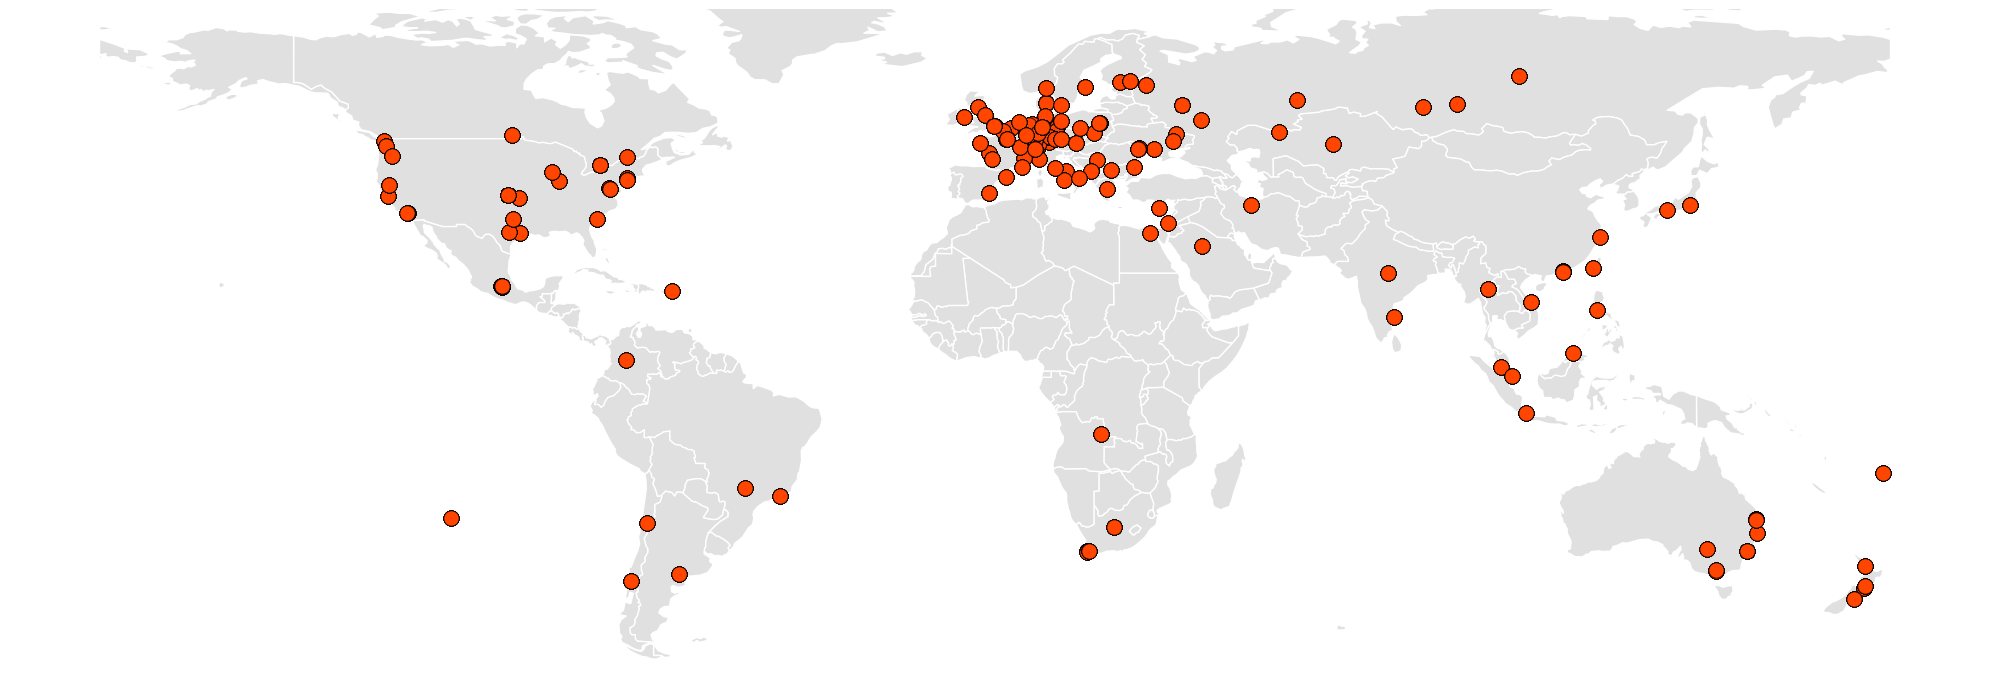

In [57]:
all_probes_locations = historical[['probe_id','latitude','longitude','haversine_distance']].drop_duplicates()
violating_probes_locations = violates_soi[['probe_id','latitude','longitude','haversine_distance']].drop_duplicates()

geometry = [Point(xy) for xy in zip(violating_probes_locations['longitude'], violating_probes_locations['latitude'])]
gdf = gpd.GeoDataFrame(violating_probes_locations, geometry=geometry)
gdf['marker'] = 'o'

# 3. Initialize the Plot
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
ax = world.plot(figsize=(20,20), color='#E0E0E0', edgecolor='white') # Light grey map


# 5. PLOT FOREGROUND
marker_styles = {
    'o': {'color': '#FF4500', 'label': 'Violating SOI Constraint'}, # Bold Orange-Red
  #  '*': {'color': '#006400', 'label': 'Root DNS'}
}

for m, subset in gdf.groupby('marker'):
    style = marker_styles.get(m, {'color': 'red', 'label': f'Marker {m}'})
    subset.plot(
        ax=ax, 
        marker=m, 
        color=style['color'], 
        markersize=120, # Slightly larger for emphasis
        alpha=1.0,      # Fully opaque
        edgecolor='black', # Add an edge to make them "pop" against the background
        linewidth=0.5,
        label=style['label'],
        zorder=2        # Forces them on top
    )

# Formatting
#ax.legend(title="", fontsize=LEGEND_FS, loc='lower left', frameon=True)
plt.ylim(-60, 75)
ax.axis('off')
plt.tight_layout()
plt.savefig(f"{figure_directory}/all_violating_probes_map.pdf",bbox_inches="tight")
plt.show()

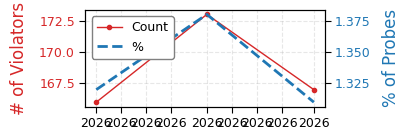

In [58]:
def plot_synchronized_trend(yemo):
    fig, ax1 = plt.subplots(figsize=(4,1.5))


    # --- Data Plotting ---
    color_abs = '#d62728' 
    lns1 = ax1.plot(yemo['snapshot'], yemo['num_ids'], color=color_abs, 
                    marker='o', label='Count', linewidth=1, markersize=3)
    
    ax2 = ax1.twinx()
    color_pct = '#1f77b4'
    lns2 = ax2.plot(yemo['snapshot'], yemo['percent_violating'], color=color_pct, 
                     label='%', linewidth=2,linestyle='--')

    ax1.tick_params(axis='y', labelcolor=color_abs, labelsize=TICK_FS-3, direction='out', length=4)
    ax2.tick_params(axis='y', labelcolor=color_pct, labelsize=TICK_FS-3, direction='out', length=4)
    ax1.tick_params(axis='x', direction='out', length=4)

    ax1.set_ylabel('# of Violators', color=color_abs, fontsize=AXIS_FS-3, labelpad=8)
    ax2.set_ylabel('% of Probes', color=color_pct, fontsize=AXIS_FS-3, labelpad=8)

    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    plt.setp(ax1.get_xticklabels(), rotation=0, ha='center', rotation_mode='anchor', fontsize=TICK_FS-3)

    ax1.grid(True, linestyle='--', alpha=0.3, zorder=0)
    ax2.grid(False) 
    ax1.set_axisbelow(True)

    # --- Legend ---
    lns = lns1 + lns2
    labs = [l.get_label() for l in lns]
    leg = ax2.legend(lns, labs, loc='upper left', frameon=True, fontsize=9, 
                     framealpha=1, facecolor='white', edgecolor='gray')
    leg.set_zorder(100)

    #plt.title("Violation Trends: Absolute vs. Relative", fontsize=TITLE_FS, pad=20)
    ax1.set_xlabel('')
    
    fig.tight_layout()
    plt.savefig(f"{figure_directory}/synchronized_violation_imc26.pdf", bbox_inches="tight")
    plt.show()

plot_synchronized_trend(yemo)

# Are anchors or probes more likely to violate?

In [59]:
anchor_metadata = all_metadata[(all_metadata['tags'].str.contains('system-anchor'))|(all_metadata['tags'].str.contains('system-virtual'))]

In [60]:
anchors = list(anchor_metadata.probe_id.unique())

In [61]:
probe_metadata = all_metadata[~all_metadata['probe_id'].isin(anchor_metadata.probe_id.unique())]

In [62]:
violates_once = historical[['probe_id','violates_two_letters_100km']].groupby('probe_id').agg({'violates_two_letters_100km':sum}).reset_index()

In [63]:
violates_once['is_anchor'] = violates_once["probe_id"].apply(lambda x: x in anchors)

In [64]:

anchor = violates_once[violates_once['is_anchor']]
probe = violates_once[~violates_once['is_anchor']]

# successes = violations
x1 = anchor["violates_two_letters_100km"].sum()
n1 = len(anchor)

x2 = probe["violates_two_letters_100km"].sum()
n2 = len(probe)

print("Anchor violation rate:", x1 / n1)
print("Probe violation rate:", x2 / n2)

count = [x1, x2]
nobs = [n1, n2]

z_stat, p_val = proportions_ztest(count, nobs)

print("z-stat:", z_stat)
print("p-value:", p_val)

risk_ratio = (x1 / n1) / (x2 / n2)
print("Risk ratio (Anchor vs Probe):", risk_ratio)

Anchor violation rate: 0.5009861932938856
Probe violation rate: 0.3996298295673633
z-stat: 6.327021079138601
p-value: 2.4993922369852936e-10
Risk ratio (Anchor vs Probe): 1.253625621081014


# Are software probes more likely to violate?

In [65]:
software_metadata = all_metadata[all_metadata['tags'].str.contains('system-software',na=False)]

In [66]:
hardware_metadata = all_metadata[all_metadata['tags'].str.contains('system-v',na=False)]

In [67]:
software_probes = software_metadata.probe_id.unique()
hardware_probes = hardware_metadata.probe_id.unique()

In [68]:
violates_once['is_soft'] = violates_once["probe_id"].apply(lambda x: x in software_probes)

In [69]:
violates_once['is_hard'] = violates_once["probe_id"].apply(lambda x: x in hardware_probes)

In [70]:
software_metadata['first_connected'] = software_metadata['probe_id'].map(probe_birthdays)
hardware_metadata['first_connected'] = hardware_metadata['probe_id'].map(probe_birthdays)

/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/256424685.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  software_metadata['first_connected'] = software_metadata['probe_id'].map(probe_birthdays)
/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/256424685.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hardware_metadata['first_connected'] = hardware_metadata['probe_id'].map(probe_birthdays)


In [71]:
# sanity check
unix_to_ymd(software_metadata['first_connected'].mean())

'20231217'

In [72]:
unix_to_ymd(hardware_metadata['first_connected'].mean())

'20170106'

In [73]:

software = violates_once[violates_once['is_soft']]
hardware = violates_once[violates_once['is_hard']]

# successes = violations
x1 = software["violates_two_letters_100km"].sum()
n1 = len(software)

x2 = hardware["violates_two_letters_100km"].sum()
n2 = len(hardware)

print("Software violation rate:", x1 / n1)
print("Hardware violation rate:", x2 / n2)

count = [x1, x2]
nobs = [n1, n2]

z_stat, p_val = proportions_ztest(count, nobs)

print("z-stat:", z_stat)
print("p-value:", p_val)

risk_ratio = (x1 / n1) / (x2 / n2)
print("Risk ratio (Software vs Hardware):", risk_ratio)

Software violation rate: 0.7686062246278755
Hardware violation rate: 0.13754368447329007
z-stat: 74.96506874871937
p-value: 0.0
Risk ratio (Software vs Hardware): 5.588088086858928


# Are old probes more likely to violate

In [74]:
copy_historical = historical.copy()

In [75]:
copy_historical['first_connected'] = copy_historical['probe_id'].map(probe_birthdays)

In [76]:
copy_historical['first_connected'] = pd.to_datetime(copy_historical['first_connected'], unit='s')

In [77]:
copy_historical["snapshot"] = pd.to_datetime(copy_historical["snapshot"])
delta = copy_historical['snapshot'] - copy_historical['first_connected']
copy_historical['age_days'] = delta.dt.days

In [78]:
import numpy as np

np.float = float
np.int = int
np.long = int

In [79]:
copy_historical = copy_historical[copy_historical["age_days"].notna()].copy()
# -----------------------------
probe_snapshot = (
    copy_historical
    .groupby(["probe_id", "snapshot"], as_index=False)
    .agg(
        age_days=("age_days", "first"),
        violates_soi=("violates_two_letters_100km", "max"),
    )
)

probe_snapshot["violates_soi"] = probe_snapshot["violates_soi"].astype(int)
probe_snapshot["age_years"] = probe_snapshot["age_days"] / 365.25
probe_snapshot["year"] = probe_snapshot["snapshot"].dt.year.astype(str)


In [80]:
probe_snapshot[probe_snapshot['violates_soi']==0]['age_days'].mean()

1934.7961037919883

In [81]:
probe_snapshot[probe_snapshot['violates_soi']==1]['age_days'].mean()

779.0533596837945

In [82]:
from scipy.stats import mannwhitneyu, chi2_contingency

viol_age = probe_snapshot.loc[probe_snapshot["violates_soi"] == 1, "age_days"]
nonviol_age = probe_snapshot.loc[probe_snapshot["violates_soi"] == 0, "age_days"]

mw_stat, mw_p = mannwhitneyu(viol_age, nonviol_age, alternative="two-sided")
n1 = len(viol_age)
n2 = len(nonviol_age)
cl = mw_stat / (n1 * n2)
print("Mann-Whitney U p-value:", mw_p)
print("Common language effect size:", cl)
print("Median age_days, violators:", viol_age.median())
print("Median age_days, non-violators:", nonviol_age.median())

Mann-Whitney U p-value: 2.0296465465407335e-77
Common language effect size: 0.2593734225662009
Median age_days, violators: 365.0
Median age_days, non-violators: 1495.0


# What kinds of ASes are more likely to violate

In [83]:
## Warning! This section is only using ASDB for the snapshot that matches the ASDB date of publication.

In [84]:
import re

CATEGORY_RULES = {
    "Hosting": r"hosting|cloud|vps|server|datacenter"}

In [85]:
def categorize(label):
    if pd.isna(label):
        return "Unknown"
    
    label = label.lower()
    
    for category, pattern in CATEGORY_RULES.items():
        if re.search(pattern, label):
            return category
    
    return "Other"

In [86]:
copy_historical = historical.copy()

In [87]:
data_matching_asdb = copy_historical[copy_historical['snapshot']==date_of_asdb]

In [88]:
asdb = pd.read_csv(f"{ASdb_input_path}")

/Users/katherineizhikevich/anaconda3/lib/python3.8/site-packages/IPython/core/interactiveshell.py:3269: DtypeWarning: Columns (13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


In [89]:
asdb['as'] = asdb['ASN'].str.replace('AS','')

In [90]:
asdb['as'] = asdb['as'].astype(float)

In [91]:
rename_map = {}
for c in asdb.columns:
    rename_map[c] = c.replace('Category ','C').replace('Layer ','L').replace(' - ','-')

In [92]:
asdb = asdb.rename(columns=rename_map)

In [93]:
min_metadata = all_metadata[['probe_id','asn_v4','asn_v6','snapshot']].drop_duplicates()

In [94]:
min_metadata = min_metadata[(min_metadata['asn_v4'].notna())|(min_metadata['asn_v6'].notna())]

In [95]:
data_matching_asdb = data_matching_asdb.merge(min_metadata,on=['probe_id','snapshot'],how='left')

In [96]:
asns_ripe = list(set(list(data_matching_asdb.asn_v4.unique()) + list(data_matching_asdb.asn_v6.unique())))

In [97]:
print(f"In march 2026, there are {len(asns_ripe)} in total.")

In march 2026, there are 0 in total.


In [98]:
print(f"Of the {len(asns_ripe)}, {asdb[asdb['as'].isin(asns_ripe)]['ASN'].nunique()} are in asdb")

Of the 0, 0 are in asdb


In [99]:
asdb["category"] = asdb["C1-L2"].apply(categorize)

In [100]:
cats = ["Internet Service Provider (ISP)","Education and Research"]
for asdb_cat in cats:
    asdb.loc[
        (asdb["C1-L2"]==asdb_cat),
        "category"
    ] = asdb_cat

In [101]:
asdb[asdb['as'].isin(asns_ripe)]['ASN'].nunique()

0

In [102]:
asdb[asdb['as'].isin(asns_ripe)]['category'].value_counts(normalize=True)

Series([], Name: category, dtype: float64)

In [103]:
asdb=asdb.set_index('as')['category'].to_dict()

In [104]:
data_matching_asdb['asn_category'] = data_matching_asdb['asn_v4'].map(asdb).fillna(data_matching_asdb['asn_v6'].map(asdb))

In [105]:
data_matching_asdb_mini = data_matching_asdb[['probe_id','asn_category','violates_two_letters_100km']].drop_duplicates()

In [106]:
contingency = pd.crosstab(
    data_matching_asdb_mini["asn_category"],
    data_matching_asdb_mini["violates_two_letters_100km"]
)

print(contingency)

Empty DataFrame
Columns: []
Index: []


In [107]:
if len(contingency)>0:
    chi2, p, dof, expected = chi2_contingency(contingency)
    print("Chi-square p-value:", p)
    n = contingency.values.sum()
    k = min(contingency.shape)

    cramers_v = np.sqrt(chi2 / (n * (k - 1)))

    print("Cramér's V:", cramers_v)
else:
    print("Check your asdb collection date.")

Check your asdb collection date.


In [108]:
data_matching_asdb_mini.groupby("asn_category")["violates_two_letters_100km"].mean().sort_values(ascending=False)

Series([], Name: violates_two_letters_100km, dtype: bool)

In [109]:
category_check = "Internet Service Provider (ISP)"
data_matching_asdb_mini["is_isp"] = (
    data_matching_asdb_mini["asn_category"] == category_check
)
isp = data_matching_asdb_mini[data_matching_asdb_mini["is_isp"]]
non_isp = data_matching_asdb_mini[~data_matching_asdb_mini["is_isp"]]

# successes = violations
x1 = isp["violates_two_letters_100km"].sum()
n1 = len(isp)

x2 = non_isp["violates_two_letters_100km"].sum()
n2 = len(non_isp)

print("ISP violation rate:", x1 / n1)
print("Non-ISP violation rate:", x2 / n2)

count = [x1, x2]
nobs = [n1, n2]

z_stat, p_val = proportions_ztest(count, nobs)

print("z-stat:", z_stat)
print("p-value:", p_val)

risk_ratio = (x1 / n1) / (x2 / n2)
print("Risk ratio (ISP vs non-ISP):", risk_ratio)

ISP violation rate: nan
Non-ISP violation rate: nan
z-stat: nan
p-value: nan
Risk ratio (ISP vs non-ISP): nan


/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/3419084030.py:15: RuntimeWarning: invalid value encountered in scalar divide
  print("ISP violation rate:", x1 / n1)
/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/3419084030.py:16: RuntimeWarning: invalid value encountered in scalar divide
  print("Non-ISP violation rate:", x2 / n2)
/Users/katherineizhikevich/anaconda3/lib/python3.8/site-packages/statsmodels/stats/proportion.py:1005: RuntimeWarning: invalid value encountered in divide
  prop = count * 1. / nobs
/Users/katherineizhikevich/anaconda3/lib/python3.8/site-packages/statsmodels/stats/proportion.py:1019: RuntimeWarning: invalid value encountered in scalar divide
  p_pooled = np.sum(count) * 1. / np.sum(nobs)
/Users/katherineizhikevich/anaconda3/lib/python3.8/site-packages/statsmodels/stats/proportion.py:1021: RuntimeWarning: divide by zero encountered in divide
  nobs_fact = np.sum(1. / nobs)
/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipyk

In [110]:
category_check = "Hosting"
data_matching_asdb_mini["is_hosting"] = (
    data_matching_asdb_mini["asn_category"] == category_check
)
hosting = data_matching_asdb_mini[data_matching_asdb_mini["is_hosting"]]
non_hosting = data_matching_asdb_mini[~data_matching_asdb_mini["is_hosting"]]

# successes = violations
x1 = hosting["violates_two_letters_100km"].sum()
n1 = len(hosting)

x2 = non_hosting["violates_two_letters_100km"].sum()
n2 = len(non_hosting)

print("Hosting violation rate:", x1 / n1)
print("Non-Hosting violation rate:", x2 / n2)

count = [x1, x2]
nobs = [n1, n2]

z_stat, p_val = proportions_ztest(count, nobs)

print("z-stat:", z_stat)
print("p-value:", p_val)

risk_ratio = (x1 / n1) / (x2 / n2)
print("Risk ratio (Hosting vs non-Hosting):", risk_ratio)

Hosting violation rate: nan
Non-Hosting violation rate: nan
z-stat: nan
p-value: nan
Risk ratio (Hosting vs non-Hosting): nan


/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/4141201752.py:15: RuntimeWarning: invalid value encountered in scalar divide
  print("Hosting violation rate:", x1 / n1)
/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/4141201752.py:16: RuntimeWarning: invalid value encountered in scalar divide
  print("Non-Hosting violation rate:", x2 / n2)
/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/4141201752.py:26: RuntimeWarning: invalid value encountered in scalar divide
  risk_ratio = (x1 / n1) / (x2 / n2)


## Probe behavior and changes over time

In [111]:
def print_minimums_per_root(df):
    gb = df.groupby(['probe_id','snapshot','root_letter']).agg({'rtt_ms':min}).reset_index()
    return gb.merge(df,on=['probe_id','rtt_ms','snapshot','root_letter'])

In [112]:
min_historical = print_minimums_per_root(historical)

In [113]:
min_historical['snapshot'] = pd.to_datetime(min_historical['snapshot'],format="%Y-%m-%d")
min_historical = min_historical.sort_values(['probe_id', 'snapshot'])

In [114]:
min_historical.head(3)

,probe_id,snapshot,root_letter,rtt_ms,hostname,site,timestamp,mid,letter,latitude,longitude,status,root_latlon,dns_lat,dns_lon,haversine_distance,furthest_possible,violates_single_letter_100km,num_violating_letters,violates_two_letters_100km
0,1,2026-05-01,a,20.842,nnn1-ams5,ams,1777593828,10309,a,52.3475,4.9275,1,"(52.3702157, 4.8951679)",52.370216,4.895168,3.346753,2082.768551,False,0,False
1,1,2026-05-01,b,27.961,b3-fra,fra,1777593736,10310,b,52.3475,4.9275,1,"(50.111, 8.682)",50.111000,8.682000,360.730942,2794.179611,False,0,False
2,1,2026-05-01,c,27.388,fra1a.c.root-servers.org,fra,1777593982,10311,c,52.3475,4.9275,1,"(50.1109221, 8.6821267)",50.110922,8.682127,360.743455,2736.918965,False,0,False


In [115]:
## This is just for the probes with violating RTTs##
n_viol = min_historical.groupby('probe_id')['violates_two_letters_100km'].sum()

# First violation snapshot  <-- NEW
first_viol_snapshot = (
    min_historical[min_historical['violates_two_letters_100km']]
    .groupby('probe_id')['snapshot']
    .min()
)

# Last violation snapshot
last_viol_snapshot = (
    min_historical[min_historical['violates_two_letters_100km']]
    .groupby('probe_id')['snapshot']
    .max()
)

# Last measurement per probe
last_snapshot = min_historical.groupby('probe_id')['snapshot'].max()

# Was the probe violating on the final snapshot?
violating_in_final = (
    min_historical[min_historical['snapshot'] == pd.Timestamp("2025-11-01")]
    .groupby('probe_id')['violates_two_letters_100km']
    .any()
)

# Combine into one table
result = pd.DataFrame({
    'n_violations': n_viol,
    'first_viol_snapshot': first_viol_snapshot,   # <-- NEW
    'last_viol_snapshot': last_viol_snapshot,
    'last_snapshot': last_snapshot,
    'violating_in_final': violating_in_final
})

# Replace missing values
result = result.fillna({
    'n_violations': 0,
    'violating_in_final': False
})

# Condition: violated >1 times, then never again, and not violating at end
result['clean_stop'] = (
    (result['n_violations'] > 1) &
    (result['last_viol_snapshot'] < result['last_snapshot']) &
    (~result['violating_in_final'])
)

In [116]:
print(len(result[result['n_violations']>0]))

241


In [117]:
violates_soi.probe_id.nunique()

241

In [118]:
stopped_violating = result[result['clean_stop']].reset_index()
print(f"{stopped_violating.probe_id.nunique()} probes stopped violating which is {stopped_violating.probe_id.nunique()*100/violates_soi.probe_id.nunique()}%.")

43 probes stopped violating which is 17.842323651452283%.


In [119]:
## This is just for the rows with violating RTTs##
n_viol = min_historical.groupby('probe_id')['violates_single_letter_100km'].sum()

# First violation snapshot  <-- NEW
first_viol_snapshot = (
    min_historical[min_historical['violates_single_letter_100km']]
    .groupby('probe_id')['snapshot']
    .min()
)

# Last violation snapshot
last_viol_snapshot = (
    min_historical[min_historical['violates_single_letter_100km']]
    .groupby('probe_id')['snapshot']
    .max()
)

# Last measurement per probe
last_snapshot = min_historical.groupby('probe_id')['snapshot'].max()

# Was the probe violating on the final snapshot?
violating_in_final = (
    min_historical[min_historical['snapshot'] == pd.Timestamp("2025-11-01")]
    .groupby('probe_id')['violates_single_letter_100km']
    .any()
)

# Combine into one table
result = pd.DataFrame({
    'n_violations': n_viol,
    'first_viol_snapshot': first_viol_snapshot,   # <-- NEW
    'last_viol_snapshot': last_viol_snapshot,
    'last_snapshot': last_snapshot,
    'violating_in_final': violating_in_final
})

# Replace missing values
result = result.fillna({
    'n_violations': 0,
    'violating_in_final': False
})

# Condition: violated >1 times, then never again, and not violating at end
result['clean_stop'] = (
    (result['n_violations'] > 1) &
    (result['last_viol_snapshot'] < result['last_snapshot']) &
    (~result['violating_in_final'])
)


In [120]:
print(len(result[result['n_violations']>0]))

316


In [121]:
all_metadata = all_metadata[~all_metadata['snapshot'].str.contains('bday')]

In [122]:
meta = all_metadata.copy()

meta['snapshot'] = pd.to_datetime(meta['snapshot'], format="%Y-%m-%d")
meta = meta.sort_values(['probe_id','snapshot'])

# create coordinate tuple (latlon)
meta['latlon'] = list(zip(meta['latitude'], meta['longitude']))

In [123]:
meta_last_viol = (
    result[['last_viol_snapshot']]
    .merge(meta[['probe_id','snapshot','latlon']], 
           left_on=['probe_id','last_viol_snapshot'],
           right_on=['probe_id','snapshot'],
           how='left')
    .rename(columns={'latlon': 'latlon_at_last_viol'})
    .drop(columns=['snapshot'])
)

In [124]:
meta_last = (
    result[['last_snapshot']]
    .merge(meta[['probe_id','snapshot','latlon']],
           left_on=['probe_id','last_snapshot'],
           right_on=['probe_id','snapshot'],
           how='left')
    .rename(columns={'latlon': 'latlon_at_last'})
    .drop(columns=['snapshot'])
)

In [125]:
result2 = (
    result
    .merge(meta_last_viol[['probe_id','latlon_at_last_viol']], on='probe_id', how='left')
    .merge(meta_last[['probe_id','latlon_at_last']], on='probe_id', how='left')
)

In [126]:
mask = (
    (result2['latlon_at_last_viol'] != result2['latlon_at_last']) & 
    (result2['n_violations'] > 0) & 
    (result2['latlon_at_last_viol'].notna())
)
meta_change_events = result2[mask]

In [127]:
meta_change_events['weeks_of_violation'] = (
    (meta_change_events['last_viol_snapshot'] - meta_change_events['first_viol_snapshot']).dt.days / 7
).round(1)

/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/3647109400.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta_change_events['weeks_of_violation'] = (


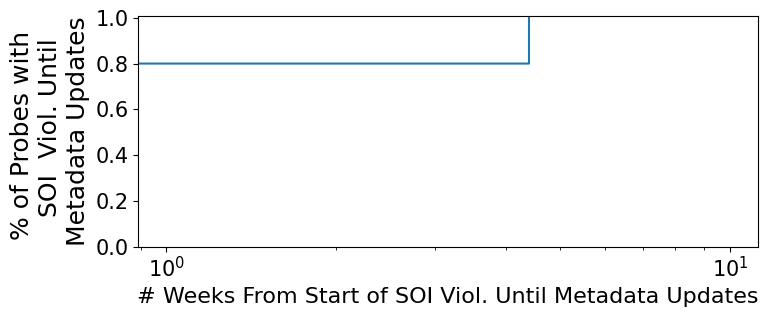

In [128]:
fig = plt.figure(figsize=(8, 3))
plt.plot(np.sort(meta_change_events['weeks_of_violation']), np.linspace(0,1,len(meta_change_events['weeks_of_violation'])))
# plt.axhline(y=0.5, color='r', linestyle='--')
# plt.axvline(x=13, color='r', linestyle='--')
plt.ylim(0,1.01)
plt.xticks(size=15)
plt.yticks(size=15)
plt.xscale('log')
plt.xlabel('# Weeks From Start of SOI Viol. Until Metadata Updates',size=16)
plt.ylabel('% of Probes with \n SOI  Viol. Until' +'\n'+ 'Metadata Updates',size=18)
plt.savefig(f"{figure_directory}/late_to_report.pdf",bbox_inches="tight")
plt.show()

In [129]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 6371.0 * (2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a)))  # km

In [130]:
meta_change_events[['lat_last_viol', 'lon_last_viol']] = meta_change_events['latlon_at_last_viol'].apply(
    lambda x: x if isinstance(x, (list, tuple)) and len(x) == 2 else [np.nan, np.nan]
).to_list()
meta_change_events[['lat_last', 'lon_last']] = meta_change_events['latlon_at_last'].apply(
    lambda x: x if isinstance(x, (list, tuple)) and len(x) == 2 else [np.nan, np.nan]
).to_list()

/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/3735915033.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta_change_events[['lat_last_viol', 'lon_last_viol']] = meta_change_events['latlon_at_last_viol'].apply(
/Users/katherineizhikevich/anaconda3/lib/python3.8/site-packages/pandas/core/indexing.py:1738: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_column(loc, value[:, i].tolist(), pi)
/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/3735915033.py

In [131]:
meta_change_events['haversine'] = haversine_distance(meta_change_events['lat_last'],meta_change_events['lon_last'],meta_change_events['lat_last_viol'],meta_change_events['lon_last_viol'])

/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/1107124987.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  meta_change_events['haversine'] = haversine_distance(meta_change_events['lat_last'],meta_change_events['lon_last'],meta_change_events['lat_last_viol'],meta_change_events['lon_last_viol'])


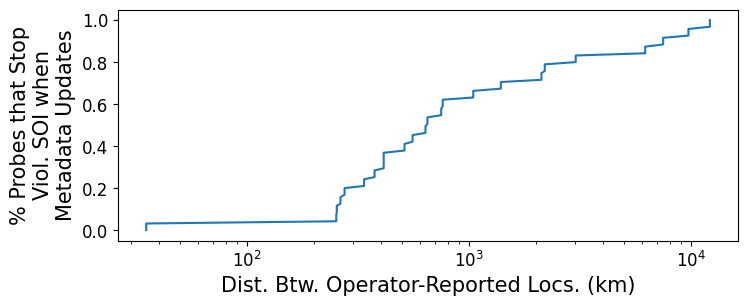

In [132]:
fig = plt.figure(figsize=(8, 3))
plt.plot(np.sort(meta_change_events['haversine']), np.linspace(0,1,len(meta_change_events['haversine'])))
plt.xticks(size=TICK_FS)
plt.yticks(size=TICK_FS)
# plt.axhline(y=0.50, color='r', linestyle='--')
# plt.axvline(x=1000, color='r', linestyle='--')
plt.xscale('log')
plt.xlabel('Dist. Btw. Operator-Reported Locs. (km)',size=AXIS_FS)
plt.ylabel('% Probes that Stop' +'\n'+ 'Viol. SOI when' +'\n'+ 'Metadata Updates',size=AXIS_FS)
plt.savefig(f"{figure_directory}/loc_change_diff_cdf.pdf", bbox_inches="tight")
plt.show()

In [133]:
violates_soi['distance_error'] = violates_soi['haversine_distance'] - violates_soi['furthest_possible']

In [134]:
max_distance_error_per_probe = violates_soi.groupby('probe_id').agg({'distance_error':max}).reset_index()

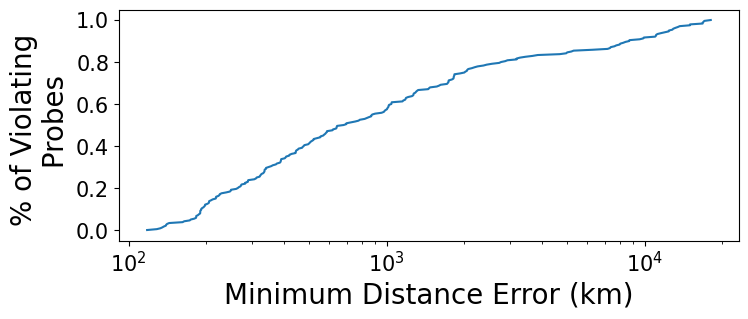

In [135]:
fig = plt.figure(figsize=(8, 3))
plt.plot(np.sort(max_distance_error_per_probe['distance_error']), np.linspace(0,1,len(max_distance_error_per_probe['distance_error'])))
plt.xscale('log')
plt.xticks(size=15)
plt.yticks(size=15)
plt.ylabel('% of Violating \n Probes',size=20)
plt.xlabel('Minimum Distance Error (km)',size=20)
plt.savefig(f"{figure_directory}/cdf_error.pdf", bbox_inches="tight")
plt.show()

# Case studies

## Violates until location change

In [136]:
print(f"{meta_change_events.probe_id.nunique()*100/violates_soi.probe_id.nunique()}% of violating probes stop violating after a latlon update")

9.95850622406639% of violating probes stop violating after a latlon update


### How many violated only once

In [137]:
probes_latlon_change = meta_change_events.probe_id.unique()

In [138]:
len(probes_latlon_change)

24

In [139]:
violates_soi_snapshots = violates_soi.groupby('probe_id').agg({'snapshot':'nunique'}).reset_index()

In [140]:
(violates_soi_snapshots[(violates_soi_snapshots['snapshot']==1)&(violates_soi_snapshots['probe_id'].isin(probes_latlon_change))].probe_id.nunique())/len(probes_latlon_change)

0.7083333333333334

In [141]:
(violates_soi_snapshots[(violates_soi_snapshots['snapshot']==1)&(violates_soi_snapshots['probe_id'].isin(probes_latlon_change))].probe_id.nunique())/violates_soi.probe_id.nunique()

0.07053941908713693

## Initial misreporting

In [142]:
mini_historical = violates_soi[['probe_id','snapshot']].drop_duplicates()

In [143]:
mini_historical = mini_historical.groupby('probe_id')['snapshot'].min().reset_index()

In [144]:
mini_historical = mini_historical.merge(all_metadata[['probe_id','first_connected']],on='probe_id',how='left')

In [145]:
mini_historical['first_connected'] = pd.to_datetime(mini_historical['first_connected'],unit='s')

/Users/katherineizhikevich/anaconda3/lib/python3.8/site-packages/pandas/core/tools/datetimes.py:345: RuntimeWarning: invalid value encountered in cast
  result, tz_parsed = tslib.array_with_unit_to_datetime(


In [146]:
mini_historical['snapshot'] = pd.to_datetime(mini_historical['snapshot'])

In [147]:
mini_historical['first_connected_lower_bound'] = mini_historical['snapshot'] - pd.DateOffset(months=1)

In [148]:
mini_historical['violator_at_birth'] = mini_historical['first_connected'] >= mini_historical['first_connected_lower_bound']

In [149]:
print(f"{mini_historical[mini_historical['violator_at_birth']].probe_id.nunique()*100/violates_soi.probe_id.nunique()}% of violating probes violate from conception")

18.25726141078838% of violating probes violate from conception


In [150]:
probes_viol_at_birth = mini_historical[mini_historical['violator_at_birth']].probe_id.unique()

In [151]:
do_both = set(probes_latlon_change) & set(probes_viol_at_birth)

In [152]:
len(do_both)

2

In [153]:
print(f"{len(do_both)*100/violates_soi.probe_id.nunique()}% of violating probes violate from conception until a metadata change")

0.8298755186721992% of violating probes violate from conception until a metadata change


In [154]:
violate_never_updated = set(probes_viol_at_birth) - set(probes_latlon_change)

In [155]:
len(set(probes_viol_at_birth))

44

In [156]:
len(violate_never_updated)*100/violates_soi.probe_id.nunique()

17.42738589211618

In [157]:
print(f"Of the {len(set(probes_latlon_change))} that violate until a latlon change, {len(do_both)} violated from conception. {len(violate_never_updated)} probes set up wrong from conception and never stop violating")

Of the 24 that violate until a latlon change, 2 violated from conception. 42 probes set up wrong from conception and never stop violating


## The remaining unclear ones

In [158]:
remaining = set(violates_soi.probe_id.unique()) - (set(probes_viol_at_birth) | set(probes_latlon_change))

In [159]:
len(remaining)/violates_soi.probe_id.nunique()

0.7385892116182573

In [160]:
len(remaining)

178

In [161]:
remaining_gb = historical[historical['probe_id'].isin(remaining)].groupby('probe_id').agg({'latitude':'nunique'}).reset_index()

In [162]:
subset = historical[historical['probe_id'].isin(remaining)].copy()

# Drop exact duplicate locations per probe (optional but usually desired)
subset = subset.drop_duplicates(subset=['probe_id', 'latitude', 'longitude'])

# Keep only probes with >1 unique location
counts = subset.groupby('probe_id')[['latitude', 'longitude']].nunique()
multi = counts[(counts['latitude'] > 1) | (counts['longitude'] > 1)].index

subset = subset[subset['probe_id'].isin(multi)].copy()

# IMPORTANT: sort by time if you have it
# If you have 'snapshot' or 'timestamp', use that:
subset = subset.sort_values(['probe_id', 'snapshot'])

# Compute shifts (previous location per probe)
subset['prev_lat'] = subset.groupby('probe_id')['latitude'].shift()
subset['prev_lon'] = subset.groupby('probe_id')['longitude'].shift()

# Compute distance between consecutive metadata changes
subset['metadata_shift_km'] = haversine_distance(
    subset['prev_lat'],
    subset['prev_lon'],
    subset['latitude'],
    subset['longitude']
)

# Drop first rows (no previous point)
movement = subset.dropna(subset=['metadata_shift_km'])

movement[['probe_id', 'metadata_shift_km']].head()

,probe_id,metadata_shift_km
162857,50525,2.166906
164970,50686,2.166864
288999,1004593,1416.863815
302652,1006162,231.699163
302653,1006162,124.981222


In [163]:
movement['metadata_shift_km'].describe()

count       30.000000
mean      2475.789546
std       4449.807083
min          0.731531
25%        151.660707
50%        432.320030
75%       1605.563189
max      13660.395297
Name: metadata_shift_km, dtype: float64

In [164]:
remaining_gb.latitude.value_counts()

1    154
2     19
3      5
Name: latitude, dtype: int64

In [165]:
remaining_gb.latitude.value_counts().tail(6).sum()

178

In [166]:
historical['latlon'] = historical['latitude'].astype(str) + ',' + historical['longitude'].astype(str)

In [167]:
remaining_gb = historical[historical['probe_id'].isin(remaining)].groupby('probe_id').agg({'latitude':'nunique'}).reset_index()

## Violate only at the same dns sites and/or hostname

In [168]:
# 1. Create the Unique Identifier
historical['root_instance'] = historical['root_letter'].str.upper() + "-" + historical['hostname']

# 2. Get the set of instances present during VIOLATING snapshots
viol_instances = (
    historical[historical['violates_single_letter_100km']]
    .groupby('probe_id')['root_instance'] 
    .apply(set)
    .reset_index(name='instances_during_violation')
)

# 3. Get the set of instances present during CLEAN snapshots
clean_instances = (
    historical[~historical['violates_single_letter_100km']]
    .groupby('probe_id')['root_instance']
    .apply(set)
    .reset_index(name='instances_during_clean')
)

# 4. Merge and Compare
comparison = pd.merge(viol_instances, clean_instances, on='probe_id', how='inner')

# Find instances that only appear when the probe is caught lying
comparison['trigger_instances'] = comparison.apply(
    lambda x: x['instances_during_violation'] - x['instances_during_clean'], axis=1
)

# A probe is "Suspect" if it has a consistent set of hostnames that trigger the flag
# while it looks perfectly fine when talking to other hostnames.
instance_suspect_probes = comparison[comparison['trigger_instances'].astype(bool)].copy()

In [169]:
hostname_dependent = instance_suspect_probes['probe_id'].unique()
hostname_dependent = set(hostname_dependent) & set(violates_soi.probe_id.unique())

In [170]:
probes_latlon_change = set(probes_latlon_change) & set(violates_soi.probe_id.unique())

In [171]:
len(probes_latlon_change)*100 / (violates_soi.probe_id.nunique())

8.71369294605809

In [172]:
probes_viol_at_birth = set(probes_viol_at_birth) & set(violates_soi.probe_id.unique())

In [173]:
len(probes_viol_at_birth)*100 / (violates_soi.probe_id.nunique())

18.25726141078838

In [174]:
len((set(probes_viol_at_birth) - set(probes_latlon_change) ) ) * 100 / (violates_soi.probe_id.nunique())

17.42738589211618

In [175]:
len((set(probes_latlon_change) | set(probes_viol_at_birth) ) ) / (violates_soi.probe_id.nunique())

0.26141078838174275

In [176]:
len((set(probes_latlon_change) | set(probes_viol_at_birth) | set(hostname_dependent))) / (violates_soi.probe_id.nunique())

0.91701244813278

In [177]:
only_hn_dependent = set(hostname_dependent) - (set(probes_latlon_change) | set(probes_viol_at_birth) )

In [178]:
len(only_hn_dependent)/(violates_soi.probe_id.nunique())

0.6556016597510373

In [179]:
only_birth_dependent = set(probes_viol_at_birth) - (set(probes_latlon_change) | set(hostname_dependent) )

In [180]:
only_change_dependent = set(probes_latlon_change) - (set(probes_viol_at_birth) | set(hostname_dependent) )

## Site dependent

In [181]:
viol_snapshots = (
    historical[historical["violates_single_letter_100km"]]
    .groupby("probe_id")["snapshot"]
    .apply(set)
    .to_dict()
)

historical["is_viol_snapshot_for_probe"] = historical.apply(
    lambda r: r["snapshot"] in viol_snapshots.get(r["probe_id"], set()),
    axis=1
)

viol_sites = (
    historical[historical["violates_single_letter_100km"]]
    .groupby("probe_id")["site"]
    .apply(lambda s: set(s.dropna()))
    .reset_index(name="sites_during_violation")
)

clean_same_snapshot_sites = (
    historical[historical["is_viol_snapshot_for_probe"] & ~historical["violates_single_letter_100km"]]
    .groupby("probe_id")["site"]
    .apply(lambda s: set(s.dropna()))
    .reset_index(name="clean_sites_same_viol_snapshots")
)

comparison = viol_sites.merge(clean_same_snapshot_sites, on="probe_id", how="left")
comparison["clean_sites_same_viol_snapshots"] = comparison["clean_sites_same_viol_snapshots"].apply(
    lambda x: x if isinstance(x, set) else set()
)

comparison["trigger_sites"] = comparison.apply(
    lambda x: x["sites_during_violation"] - x["clean_sites_same_viol_snapshots"],
    axis=1
)

suspect_probes = comparison[comparison["trigger_sites"].astype(bool)].copy()

In [182]:
site_dependent = suspect_probes['probe_id'].unique()
site_dependent = set(site_dependent) & set(violates_soi.probe_id.unique())

In [183]:
only_site_dependent = set(site_dependent) - (set(probes_latlon_change) | set(hostname_dependent) |set(probes_viol_at_birth) )

In [184]:
len(only_site_dependent)*100/(violates_soi.probe_id.nunique())

7.468879668049793

In [185]:
len((set(probes_latlon_change) | set(probes_viol_at_birth) | set(hostname_dependent)| set(site_dependent))) / (violates_soi.probe_id.nunique())

0.991701244813278

# Ablation studies

In [186]:
def compute_max_one_way_km_from_rtt(rtt_ms, propagation_speed_km_s=199_862.638):
    """
    Convert measured RTT (ms) into the maximum possible one-way distance (km),
    assuming the signal propagated at `propagation_speed_km_s`.

    Default speed is ~ (2/3) * c in km/s.
    """
    return (propagation_speed_km_s * rtt_ms / 1000.0) / 2.0


def compute_haversine_km(lat1, lon1, lat2, lon2):
    """
    Vectorized haversine distance in km.
    """
    lat1, lon1, lat2, lon2 = map(
        np.radians, [lat1, lon1, lat2, lon2]
    )
    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    return 6371.0 * (2.0 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a)))


# -----------------------------------------
# ablation-friendly annotation functions
# -----------------------------------------
def annotate_letter_level_constraints(
    df,
    *,
    tolerance_km=100,
    propagation_speed_km_s=199_862.638,
    lat_col="latitude",
    lon_col="longitude",
    dns_lat_col="dns_lat",
    dns_lon_col="dns_lon",
    rtt_col="rtt_ms",
    distance_col="gc_distance_km",
    max_dist_col="max_feasible_km",
    violation_col="violates_letter_constraint",
):
    """
    Adds per-row distance / feasibility columns and a per-letter violation flag.

    A row violates when:
        max_feasible_km + tolerance_km < geographic_distance_km
    """
    out = df.copy()

    out[distance_col] = compute_haversine_km(
        out[lat_col],
        out[lon_col],
        out[dns_lat_col],
        out[dns_lon_col],
    )

    out[max_dist_col] = compute_max_one_way_km_from_rtt(
        out[rtt_col],
        propagation_speed_km_s=propagation_speed_km_s,
    )

    out[violation_col] = (
        out[max_dist_col] + tolerance_km < out[distance_col]
    )

    return out


def annotate_snapshot_level_agreement(
    df,
    *,
    min_letters=2,
    probe_col="probe_id",
    snapshot_col="snapshot",
    root_col="root_letter",
    letter_violation_col="violates_letter_constraint",
    snapshot_violation_col="violates_snapshot_constraint",
):
    """
    Aggregates letter-level violations up to the (probe, snapshot) level.

    A probe snapshot violates if it has violations from at least `min_letters`
    distinct root letters.
    """
    out = df.copy()

    violating_letters = (
        out.loc[out[letter_violation_col], [probe_col, snapshot_col, root_col]]
        .drop_duplicates()
        .groupby([probe_col, snapshot_col])[root_col]
        .nunique()
        .reset_index(name="num_violating_letters_ablation")
    )

    violating_letters[snapshot_violation_col] = (
        violating_letters["num_violating_letters_ablation"] >= min_letters
    )

    out = out.merge(
        violating_letters[
            [probe_col, snapshot_col, "num_violating_letters_ablation", snapshot_violation_col]
        ],
        on=[probe_col, snapshot_col],
        how="left",
    )

    out["num_violating_letters_ablation"] = out["num_violating_letters_ablation"].fillna(0).astype(int)
    out[snapshot_violation_col] = out[snapshot_violation_col].fillna(False)

    return out


def annotate_location_level_persistence(
    df,
    *,
    probe_col="probe_id",
    lat_col="latitude",
    lon_col="longitude",
    snapshot_violation_col="violates_snapshot_constraint",
    location_violation_col="violates_any_snapshot_at_location",
):
    """
    Aggregates snapshot-level violations up to the (probe, reported location) level.
    """
    out = df.copy()

    loc_flags = (
        out.groupby([probe_col, lat_col, lon_col], as_index=False)[snapshot_violation_col]
        .any()
        .rename(columns={snapshot_violation_col: location_violation_col})
    )

    out = out.merge(
        loc_flags,
        on=[probe_col, lat_col, lon_col],
        how="left",
    )
    out[location_violation_col] = out[location_violation_col].fillna(False)

    return out


def run_soi_ablation_pipeline(
    df,
    *,
    tolerance_km=100,
    min_letters=2,
    propagation_speed_km_s=199_862.638,
    lat_col="latitude",
    lon_col="longitude",
    dns_lat_col="dns_lat",
    dns_lon_col="dns_lon",
    rtt_col="rtt_ms",
    probe_col="probe_id",
    snapshot_col="snapshot",
    root_col="root_letter",
):
    """
    Full ablation-friendly pipeline.

    Returns a dataframe annotated with:
      - gc_distance_km
      - max_feasible_km
      - violates_letter_constraint
      - num_violating_letters_ablation
      - violates_snapshot_constraint
      - violates_any_snapshot_at_location
    """
    out = annotate_letter_level_constraints(
        df,
        tolerance_km=tolerance_km,
        propagation_speed_km_s=propagation_speed_km_s,
        lat_col=lat_col,
        lon_col=lon_col,
        dns_lat_col=dns_lat_col,
        dns_lon_col=dns_lon_col,
        rtt_col=rtt_col,
        distance_col="gc_distance_km",
        max_dist_col="max_feasible_km",
        violation_col="violates_letter_constraint",
    )

    out = annotate_snapshot_level_agreement(
        out,
        min_letters=min_letters,
        probe_col=probe_col,
        snapshot_col=snapshot_col,
        root_col=root_col,
        letter_violation_col="violates_letter_constraint",
        snapshot_violation_col="violates_snapshot_constraint",
    )

    out = annotate_location_level_persistence(
        out,
        probe_col=probe_col,
        lat_col=lat_col,
        lon_col=lon_col,
        snapshot_violation_col="violates_snapshot_constraint",
        location_violation_col="violates_any_snapshot_at_location",
    )

    return out

In [187]:
ablations = historical.copy()

In [188]:
# baseline: 100 km, 2 letters, 2/3 c
baseline = run_soi_ablation_pipeline(
    ablations,
    tolerance_km=100,
    min_letters=2,
    propagation_speed_km_s=199_862.638,
)

# ablation 1: remove 100 km tolerance
ablation_0km = run_soi_ablation_pipeline(
    ablations,
    tolerance_km=0,
    min_letters=2,
    propagation_speed_km_s=199_862.638,
)

# ablation 2: 1-letter agreement instead of 2
ablation_1letter = run_soi_ablation_pipeline(
    ablations,
    tolerance_km=100,
    min_letters=1,
    propagation_speed_km_s=199_862.638,
)

# ablation 3: absolute 4/9c instead of 2/3 c
C_KM_S = 299_792.458
katz_speed = C_KM_S*(4/9)
ablation_katz = run_soi_ablation_pipeline(
    ablations,
    tolerance_km=100,
    min_letters=2,
    propagation_speed_km_s=katz_speed,
)

In [189]:
probes_per_snapshot_0km = (
    ablation_0km.loc[ablation_0km["violates_snapshot_constraint"]]
    .groupby("snapshot")["probe_id"]
    .nunique()
    .reset_index(name="num_ids_0km")
    .sort_values("snapshot")
)
probes_per_snapshot_0km['snapshot'] = pd.to_datetime(probes_per_snapshot_0km['snapshot'])

In [190]:
probes_per_snapshot_1letter = (
    ablation_1letter.loc[ablation_1letter["violates_snapshot_constraint"]]
    .groupby("snapshot")["probe_id"]
    .nunique()
    .reset_index(name="num_ids_1letter")
    .sort_values("snapshot")
)
probes_per_snapshot_1letter['snapshot'] = pd.to_datetime(probes_per_snapshot_1letter['snapshot'])

In [191]:
probes_per_snapshot_katzC = (
    ablation_katz.loc[ablation_katz["violates_snapshot_constraint"]]
    .groupby("snapshot")["probe_id"]
    .nunique()
    .reset_index(name="num_ids_katz")
    .sort_values("snapshot")
)
probes_per_snapshot_katzC['snapshot'] = pd.to_datetime(probes_per_snapshot_katzC['snapshot'])

In [192]:
yemo['snapshot'] = pd.to_datetime(yemo['snapshot'])

In [193]:
yemo = yemo.merge(probes_per_snapshot_0km,on='snapshot',how='left')

In [194]:
yemo = yemo.merge(probes_per_snapshot_1letter,on='snapshot',how='left')

In [195]:
yemo = yemo.merge(probes_per_snapshot_katzC,on='snapshot',how='left')

In [196]:
yemo.columns

Index(['snapshot', 'num_ids', 'num_total', 'percent_violating', 'num_ids_0km',
       'num_ids_1letter', 'num_ids_katz'],
      dtype='object')

/var/folders/vs/75zkfrf1717gw23brlhbcsqw0000gn/T/ipykernel_92104/471927709.py:15: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)


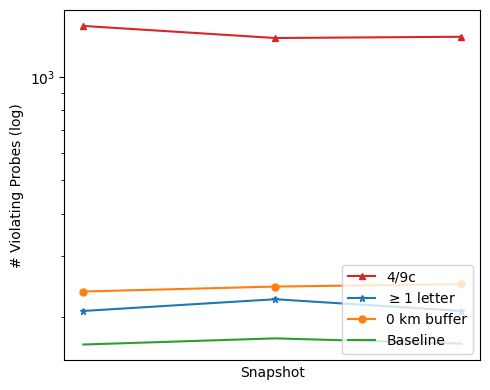

In [197]:
yemo = yemo.copy()
yemo["snapshot"] = pd.to_datetime(yemo["snapshot"])
yemo = yemo.sort_values("snapshot")

fig, ax = plt.subplots(figsize=(5,4))

ax.plot(yemo["snapshot"], yemo["num_ids_katz"], marker="^",markersize=5,color='tab:red', label="4/9c")
ax.plot(yemo["snapshot"], yemo["num_ids_1letter"],marker="*" ,markersize=5,color='tab:blue',label=r"$\geq 1$ letter")# label="At least 1-letter")
ax.plot(yemo["snapshot"], yemo["num_ids_0km"], marker="o",markersize=5,color='tab:orange', label="0 km buffer")
ax.plot(yemo["snapshot"], yemo["num_ids"], linestyle="-",markersize=5,color='tab:green',label="Baseline")

ax.set_xlabel("Snapshot")
ax.set_ylabel("# Violating Probes (log)")
ax.set_yscale("log")
ax.set_ylim(bottom=0)

years = pd.date_range(
    start=yemo["snapshot"].min().normalize(),
    end=yemo["snapshot"].max().normalize(),
    freq="YS"
)
ax.set_xticks(years)
ax.tick_params(axis="x", rotation=45)

ax.legend(loc="lower right")
#plt.title("Ablation Study: Violating Probes per Snapshot")
plt.tight_layout()
plt.savefig(f"{figure_directory}/ablations_katz.pdf",bbox_inches="tight")
plt.show()

In [198]:
avg_diff = (yemo['num_ids_0km'] - yemo['num_ids']).mean()

In [199]:
avg_diff

75.0

In [200]:
avg_diff = (yemo['num_ids_katz'] - yemo['num_ids']).mean()

In [201]:
avg_diff

1172.6666666666667

In [202]:
avg_diff = (yemo['num_ids_1letter'] - yemo['num_ids']).mean()

In [203]:
avg_diff

45.0

## Why we can't do 0km:

In [204]:
historical['root_hn'] = historical['root_letter']+'_'+historical['hostname']

In [205]:
hostname_data = historical[['root_letter','root_hn','root_latlon']].drop_duplicates()

In [206]:
hdgb = hostname_data.groupby('root_latlon').agg({'root_letter':set}).reset_index()

In [207]:
hdgb['num_letters'] = hdgb['root_letter'].apply(len)

In [208]:
print(f"{len(hdgb[hdgb['num_letters']>1])*100/len(hdgb)}% are in the same place across multiple different root letters. And the majority are not for root A and K which are both operated by Verisign.")

9.219088937093275% are in the same place across multiple different root letters. And the majority are not for root A and K which are both operated by Verisign.


In [209]:
hdgb['root_letter'] = hdgb['root_letter'].astype(str)

In [210]:
hdgb[hdgb['num_letters']>1]['root_letter'].value_counts()

{'e', 'f'}                   37
{'l', 'k'}                   12
{'a', 'j'}                    5
{'d', 'c'}                    5
{'a', 'e', 'j'}               4
{'d', 'k'}                    4
{'m', 'f'}                    3
{'a', 'd', 'j'}               2
{'a', 'f', 'j'}               2
{'d', 'f'}                    2
{'a', 'm', 'd', 'j'}          1
{'a', 'd', 'j', 'c'}          1
{'m', 'c'}                    1
{'a', 'e', 'f', 'j'}          1
{'l', 'm'}                    1
{'d', 'a', 'c', 'm', 'j'}     1
{'d', 'm'}                    1
{'a', 'e', 'f'}               1
{'d', 'm', 'j'}               1
Name: root_letter, dtype: int64